## Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for professional-looking graphs
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16})

## Data Loading

In [2]:
DATA_DIR = "datasets/"
CHUCK_SIZE = 500000

# 1. Load a chunk of the RAW 1K data for temporal analysis
PATH_1K = DATA_DIR + "lastfm-dataset-1K/userid-timestamp-artid-artname-traid-traname.tsv"
COLS_1K = ["user_id", "timestamp", "artist_id", "artist_name", "track_id", "track_name"]
df_raw = pd.read_csv(PATH_1K, sep='\t', names=COLS_1K, on_bad_lines='skip', quoting=3, nrows=CHUCK_SIZE)
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])

# 2. Load the PREPROCESSED training sessions
train_1k = pd.read_pickle("datasets/processed/train/session_train.pkl")

# 3. Load Vocabularies to map IDs back to human-readable names
with open("datasets/processed/track_vocab.pkl", "rb") as f:
    track2idx = pickle.load(f)["track2idx"]
    idx2track = {v: k for k, v in track2idx.items()}

with open("datasets/processed/artist_vocab.pkl", "rb") as f:
    artist2idx = pickle.load(f)["artist2idx"]
    idx2artist = {v: k for k, v in artist2idx.items()}

print("Data loaded successfully!")

Data loaded successfully!


## The Long-Tail Distribution (Popularity Bias)

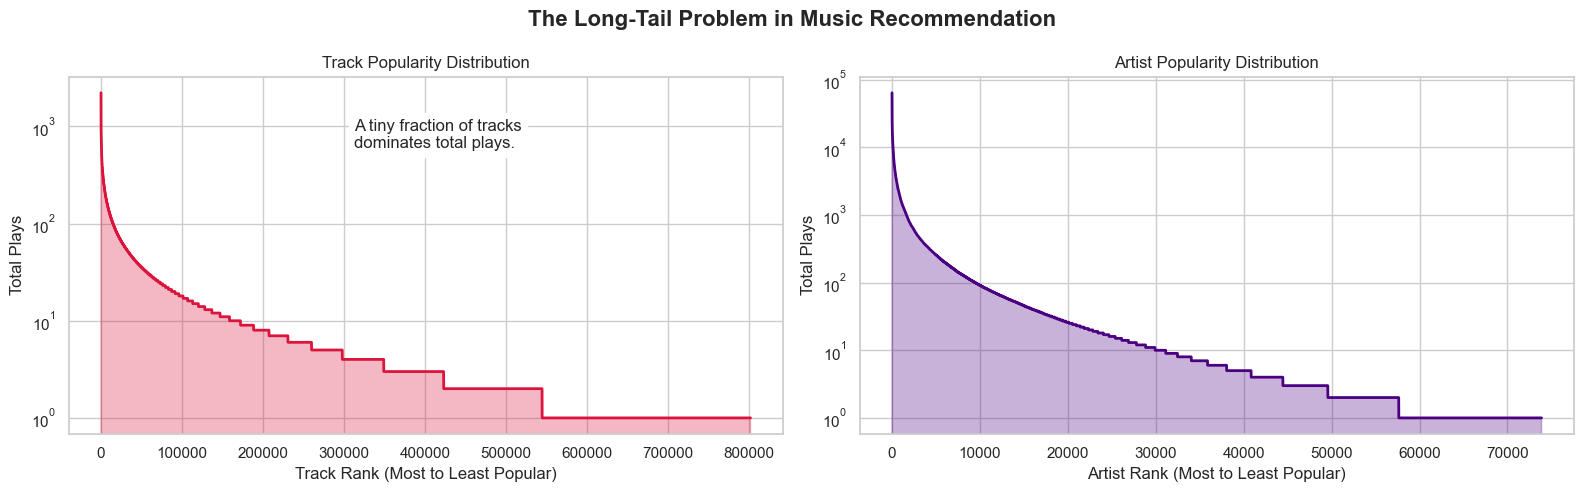

In [3]:
# Flatten preprocessed tracks and artists
all_tracks = [track for session in train_1k['track_key'] for track in session]
all_artists = [artist for session in train_1k['artist_key'] for artist in session]

track_counts = Counter(all_tracks)
artist_counts = Counter(all_artists)

sorted_tracks = sorted(track_counts.values(), reverse=True)
sorted_artists = sorted(artist_counts.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("The Long-Tail Problem in Music Recommendation", fontweight='bold')

# Track Popularity
axes[0].plot(sorted_tracks, color="crimson", linewidth=2)
axes[0].fill_between(range(len(sorted_tracks)), sorted_tracks, color="crimson", alpha=0.3)
axes[0].set_title("Track Popularity Distribution")
axes[0].set_xlabel("Track Rank (Most to Least Popular)")
axes[0].set_ylabel("Total Plays")
axes[0].set_yscale("log") 
axes[0].text(0.4, 0.8, 'A tiny fraction of tracks\ndominates total plays.', 
             transform=axes[0].transAxes, bbox=dict(facecolor='white', alpha=0.9))

# Artist Popularity
axes[1].plot(sorted_artists, color="indigo", linewidth=2)
axes[1].fill_between(range(len(sorted_artists)), sorted_artists, color="indigo", alpha=0.3)
axes[1].set_title("Artist Popularity Distribution")
axes[1].set_xlabel("Artist Rank (Most to Least Popular)")
axes[1].set_ylabel("Total Plays")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

## Session Characteristics

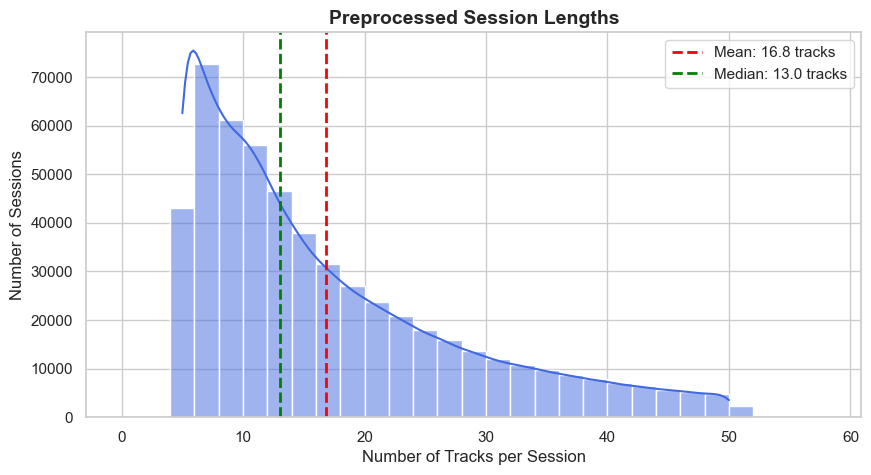

In [4]:
session_lengths = train_1k['track_key'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(session_lengths, bins=range(0, 60, 2), kde=True, color="royalblue")
plt.title("Preprocessed Session Lengths", fontsize=14, fontweight='bold')
plt.xlabel("Number of Tracks per Session")
plt.ylabel("Number of Sessions")

mean_len = session_lengths.mean()
median_len = session_lengths.median()

plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_len:.1f} tracks')
plt.axvline(median_len, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_len:.1f} tracks')
plt.legend()
plt.show()

## Temporal Listening Habits

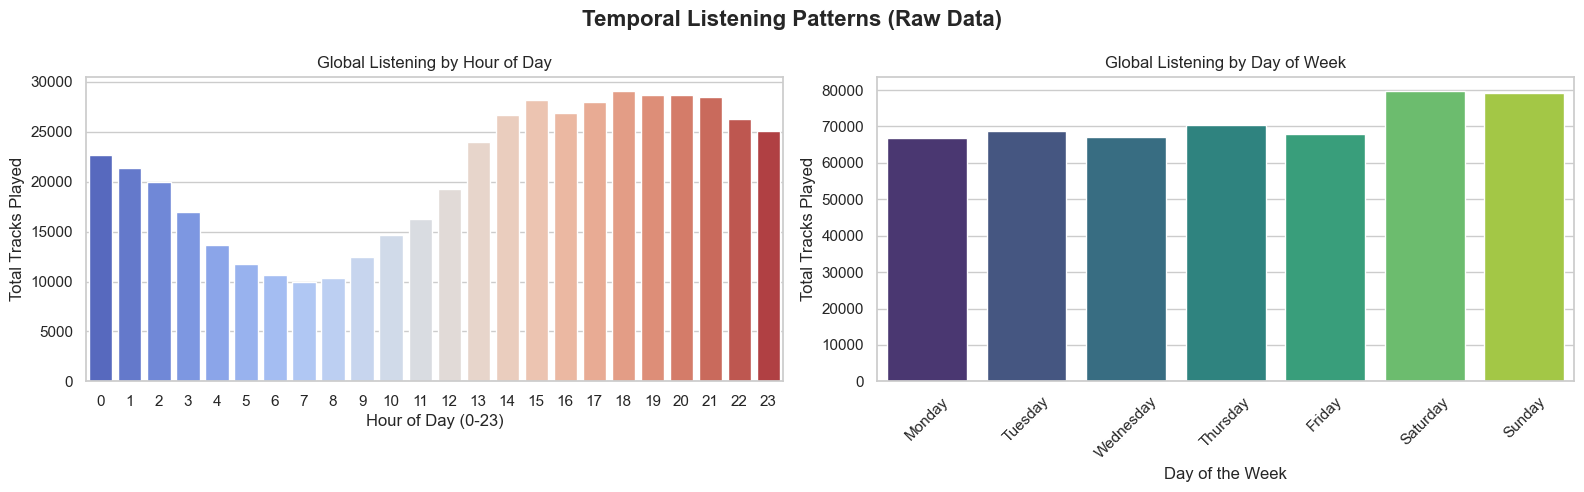

In [5]:
# Extract hour and day of week from the raw timestamps
df_raw['hour'] = df_raw['timestamp'].dt.hour
df_raw['day_of_week'] = df_raw['timestamp'].dt.day_name()

# Order days correctly
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Temporal Listening Patterns (Raw Data)", fontweight='bold')

# Listening by Hour
sns.countplot(x='hour', data=df_raw, ax=axes[0], palette="coolwarm")
axes[0].set_title("Global Listening by Hour of Day")
axes[0].set_xlabel("Hour of Day (0-23)")
axes[0].set_ylabel("Total Tracks Played")

# Listening by Day of Week
sns.countplot(x='day_of_week', data=df_raw, ax=axes[1], order=days_order, palette="viridis")
axes[1].set_title("Global Listening by Day of Week")
axes[1].set_xlabel("Day of the Week")
axes[1].set_ylabel("Total Tracks Played")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Top 10 Most Played Content 

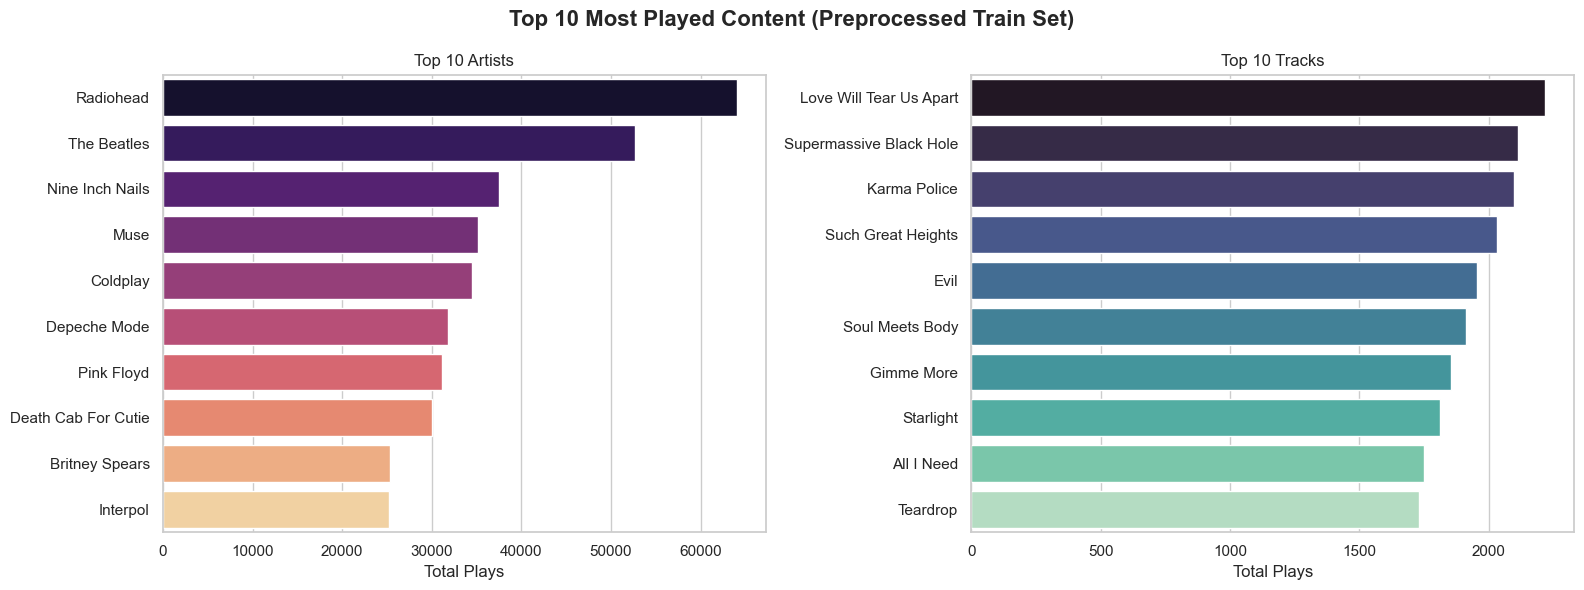

In [6]:
# Map the top 10 IDs back to their human-readable names
top_10_artist_ids = [aid for aid, count in artist_counts.most_common(10) if aid != 0] # exclude <PAD>
top_10_artist_counts = [count for aid, count in artist_counts.most_common(10) if aid != 0]

top_10_track_ids = [tid for tid, count in track_counts.most_common(10) if tid != 0]
top_10_track_counts = [count for tid, count in track_counts.most_common(10) if tid != 0]

# Extract names from the "ID:::Name" string format
top_10_artist_names = [idx2artist.get(idx, "Unknown").split(":::")[-1] for idx in top_10_artist_ids]
top_10_track_names = [idx2track.get(idx, "Unknown").split(":::")[-1] for idx in top_10_track_ids]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top 10 Most Played Content (Preprocessed Train Set)", fontweight='bold')

# Artists
sns.barplot(x=top_10_artist_counts, y=top_10_artist_names, ax=axes[0], palette="magma")
axes[0].set_title("Top 10 Artists")
axes[0].set_xlabel("Total Plays")

# Tracks
sns.barplot(x=top_10_track_counts, y=top_10_track_names, ax=axes[1], palette="mako")
axes[1].set_title("Top 10 Tracks")
axes[1].set_xlabel("Total Plays")

plt.tight_layout()
plt.show()

Loading data and calculating metrics (this might take a few seconds)...
Calculations complete! Plotting graphs...


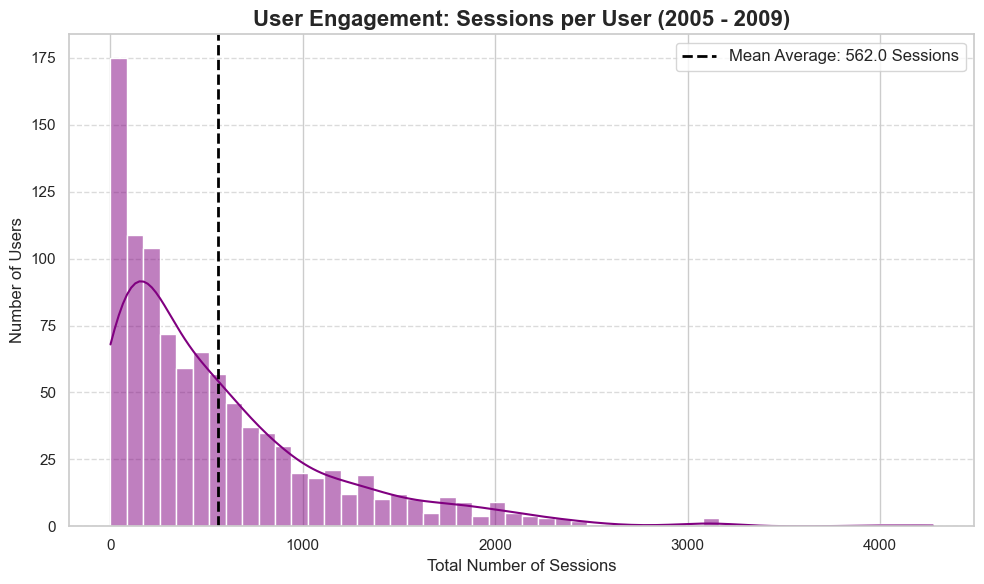

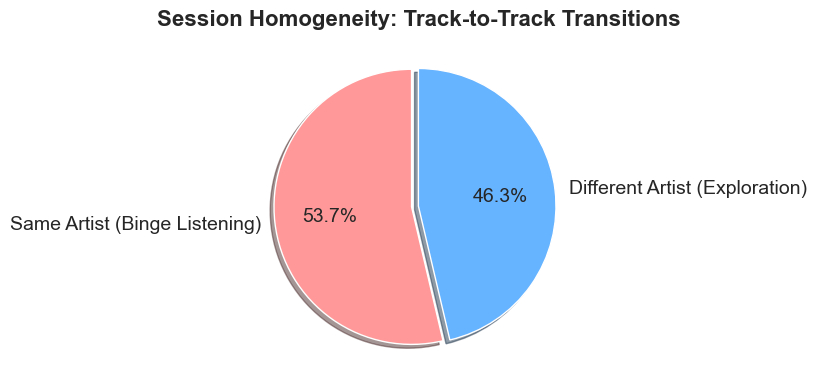

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading data and calculating metrics (this might take a few seconds)...")

# 1. Load the preprocessed sequence data
# (Make sure this path matches your folder structure)
train_1k = pd.read_pickle("datasets/processed/train/session_train.pkl")

# 2. Calculate User Activity (How many sessions belong to each user)
sessions_per_user = train_1k['user_key'].value_counts()

# 3. Calculate Artist Binge-Listening (Track-to-Track transitions)
consecutive_artist_plays = 0
total_transitions = 0

# Loop through every session's list of artists
for session in train_1k['artist_key']:
    if len(session) > 1:
        for i in range(len(session) - 1):
            total_transitions += 1
            # If the current artist is the same as the next artist in the queue
            if session[i] == session[i+1]:
                consecutive_artist_plays += 1

print("Calculations complete! Plotting graphs...")

# --- GRAPH 1: User Activity Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(sessions_per_user, bins=50, kde=True, color="purple")

plt.title("User Engagement: Sessions per User (2005 - 2009)", fontweight='bold', fontsize=16)
plt.xlabel("Total Number of Sessions", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)

# Add a line for the mean average
plt.axvline(sessions_per_user.mean(), color='black', linestyle='dashed', linewidth=2, 
            label=f'Mean Average: {sessions_per_user.mean():.1f} Sessions')
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------

# --- GRAPH 2: Artist Homogeneity Pie Chart ---
plt.figure(figsize=(8, 8))

# Data to plot
sizes = [consecutive_artist_plays, total_transitions - consecutive_artist_plays]
labels = ['Same Artist (Binge Listening)', 'Different Artist (Exploration)']
colors = ['#ff9999','#66b3ff']
explode = (0.05, 0) # slightly "explode" the first slice for emphasis

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', 
        shadow=True, startangle=90, textprops={'fontsize': 14})

plt.title("Session Homogeneity: Track-to-Track Transitions", fontweight='bold', fontsize=16)

plt.tight_layout()
plt.show()